In [11]:
import pandas as pd
df= pd.read_csv('online_retail.csv', encoding='ISO-8859-1')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [12]:
print(df.isnull().sum())
print(df.shape)
df = df.dropna(subset=['CustomerID'])
df= df[~df['InvoiceNo'].astype(str).str.startswith('C')]
df= df [(df['Quantity']>0) & (df['UnitPrice'] > 0)]
print(df.shape)

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64
(541909, 8)
(397884, 8)


In [13]:
import sqlite3
conn = sqlite3.connect('retail.db')
df.to_sql('transactions' , conn , if_exists='replace' , index=False)
print("Data is saved in database")

Data is saved in database


In [14]:
query = """
SELECT
CustomerID,
MAX(InvoiceDate) as LastPurchaseDate,
COUNT(DISTINCT InvoiceNo) as Frequency,
SUM(Quantity * UnitPrice) as Monetary
FROM transactions
GROUP BY CustomerID
"""
rfm_raw = pd.read_sql(query , conn)
rfm_raw.head()

,CustomerID,LastPurchaseDate,Frequency,Monetary
0,12346.0,2011-01-18 10:01:00,1,77183.60
1,12347.0,2011-12-07 15:52:00,7,4310.00
2,12348.0,2011-09-25 13:13:00,4,1797.24
3,12349.0,2011-11-21 09:51:00,1,1757.55
4,12350.0,2011-02-02 16:01:00,1,334.40


In [15]:
from datetime import datetime
rfm_raw['LastPurchaseDate'] =  pd.to_datetime(rfm_raw['LastPurchaseDate'])
reference_date = rfm_raw['LastPurchaseDate'].max() + pd.Timedelta(days=1)
rfm_raw['Recency'] = (reference_date - rfm_raw['LastPurchaseDate']).dt.days
rfm_raw.head()

,CustomerID,LastPurchaseDate,Frequency,Monetary,Recency
0,12346.0,2011-01-18 10:01:00,1,77183.60,326
1,12347.0,2011-12-07 15:52:00,7,4310.00,2
2,12348.0,2011-09-25 13:13:00,4,1797.24,75
3,12349.0,2011-11-21 09:51:00,1,1757.55,19
4,12350.0,2011-02-02 16:01:00,1,334.40,310


In [16]:
from sklearn.preprocessing import StandardScaler
rfm = rfm_raw[['CustomerID' , 'Recency' , 'Frequency' , 'Monetary']]
features = rfm[['Recency' , 'Frequency' , 'Monetary']]
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(features)
rfm_scaled[:5]

array([[ 2.33457414, -0.4250965 ,  8.35866818],
       [-0.90534032,  0.3544168 ,  0.25096626],
       [-0.17535959, -0.03533985, -0.02859601],
       [-0.73534481, -0.4250965 , -0.0330118 ],
       [ 2.17457836, -0.4250965 , -0.19134727]])

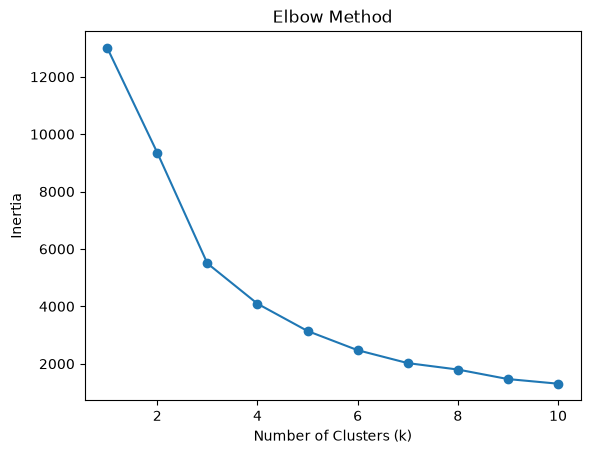

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(k_range, inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()


In [18]:
kmeans = KMeans(n_clusters=4 , random_state = 42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)
rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346.0,326,1,77183.60,3
1,12347.0,2,7,4310.00,0
2,12348.0,75,4,1797.24,0
3,12349.0,19,1,1757.55,0
4,12350.0,310,1,334.40,1


In [19]:
cluster_summary = rfm.groupby('Cluster')[['Recency' , 'Frequency' , 'Monetary']].mean()
cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,43.702685,3.682711,1359.049284
1,248.075914,1.552015,480.617480
2,7.384615,82.538462,127338.313846
3,15.500000,22.333333,12709.090490


In [22]:
cluster_names = {
    2: 'Champions',
    3: 'Loyal Customers',
    0: 'Average Customers',
    1: 'At Risk/Lost'
}
rfm['Segment'] = rfm['Cluster'].map(cluster_names)
rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster,Segment
0,12346.0,326,1,77183.60,3,Loyal Customers
1,12347.0,2,7,4310.00,0,Average Customers
2,12348.0,75,4,1797.24,0,Average Customers
3,12349.0,19,1,1757.55,0,Average Customers
4,12350.0,310,1,334.40,1,At Risk/Lost


In [23]:
rfm['Segment'].value_counts()

Segment
Average Customers    3054
At Risk/Lost         1067
Loyal Customers       204
Champions              13
Name: count, dtype: int64

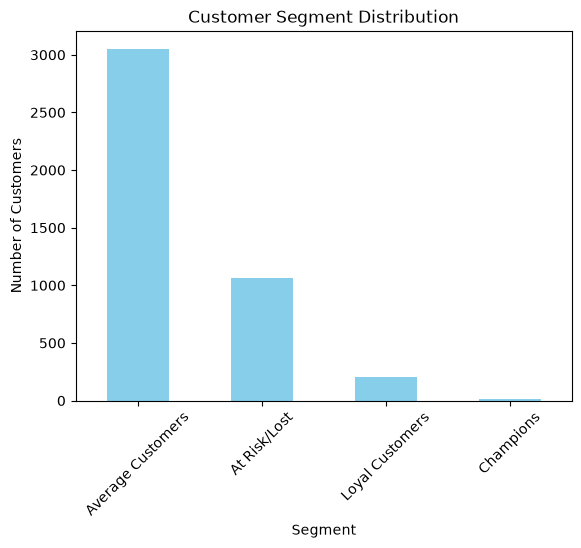

In [ ]:
import matplotlib.pyplot as plt
rfm['Segment'].value_counts().plot(kind='bar' , color='skyblue')
plt.title('Customer Segment Distribution')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.savefig('segment_distribution.png', bbox_inches='tight')
plt.show()

In [ ]:
import plotly.express as px

fig = px.scatter_3d(
    rfm,
    x='Recency',
    y='Frequency',
    z='Monetary',
    color='Segment',
    title='Customer Segments - 3D View (RFM)',
    opacity=0.7
)
fig.write_image('rfm_3d_clusters.png')
fig.show()